# Notebook for Comparing Augmentation Techniques

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import zipfile
import os

shutil.copy("/content/drive/MyDrive/deeplearning/data/DLProjectData/RoCoLeDataset.zip", "/content/RoCoLeDataset.zip")
shutil.copy("/content/drive/MyDrive/deeplearning/data/DLProjectData/CLRDataset.zip", "/content/CLRDataset.zip")

with zipfile.ZipFile("/content/RoCoLeDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/RoCoLeDataset_Local")
    
with zipfile.ZipFile("/content/CLRDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDataset_Local")
    
clean_data_path = "/content/RoCoLeDataset_Local/RoCoLeDataset"
messy_data_path = "/content/CLRDataset_Local/CLRDataset"

Mounted at /content/drive


## Setting Up Different Augmentation Techniques

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#Baseline normalization and validation transformation

base_post_transforms = [
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    *base_post_transforms
])

Using device: cuda:0


## Single Augmentation List

In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

class AlbumentationsWrapper:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, img):
        img = np.array(img)
        augmented = self.transform(image=img)
        return augmented['image']

norm_and_tensor = [
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
]

base_experiments = {
    
    "Baseline": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        *norm_and_tensor
    ])),

    "Color Jitter": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.05, p=1.0),
        *norm_and_tensor
    ])),
    
    "Gaussian Blur": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.GaussianBlur(blur_limit=(5, 9), sigma_limit=(0.1, 2.0), p=1.0),
        *norm_and_tensor
    ])),

    "Gaussian Noise": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.GaussNoise(std_range=(0.1, 0.2), p=1.0),
        *norm_and_tensor
    ])),

    "Random Brightness": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        *norm_and_tensor
    ])),
    
    "Horizontal Flip": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=1.0),
        *norm_and_tensor
    ])),
    
    "Rotation (90)": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.Rotate(limit=90, p=1.0),
        *norm_and_tensor
    ])),

    "CLAHE": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
        *norm_and_tensor
    ])),
    
    "Aggressive Crop": AlbumentationsWrapper(A.Compose([
        A.RandomResizedCrop(size=(224, 224), scale=(0.05, 0.3), p=1.0),
        *norm_and_tensor

    ])),
    
    "Grid Dropout": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.GridDropout(ratio=0.2, random_offset=True, p=1.0),
        *norm_and_tensor
    ])),
    
    "Simulated Rain & Shadow": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.RandomShadow(p=0.5),
        A.RandomRain(p=0.5),
        *norm_and_tensor
    ])),

}

## Loading Data, Creating Models

In [4]:
def get_dataloaders(train_transform):
    """Creates fresh dataloaders for a specific training transform."""
    full_train_dataset = datasets.ImageFolder(clean_data_path, transform=train_transform)
    full_val_dataset = datasets.ImageFolder(clean_data_path, transform=val_transforms)

    targets = full_train_dataset.targets
    train_idx, val_idx = train_test_split(
        range(len(targets)), test_size=0.20, random_state=42, stratify=targets 
    )

    train_dataset = Subset(full_train_dataset, train_idx)
    test_dataset = Subset(full_val_dataset, val_idx)

    # Full Eval Dataset (No subsetting)
    eval_data = datasets.ImageFolder(root=messy_data_path, transform=val_transforms)
    
    def binary_target_transform(label_idx):
        class_name = eval_data.classes[label_idx]
        return 0 if class_name == '0' else 1
    eval_data.target_transform = binary_target_transform

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
    eval_loader = DataLoader(eval_data, batch_size=32, shuffle=False, num_workers=2)

    return train_loader, test_loader, eval_loader, len(train_dataset), len(test_dataset), len(eval_data)


def train_evaluate_model(train_loader, test_loader, eval_loader, train_size, val_size, eval_size, num_epochs=20, train_deeper=False, lr=0.001):
    #Initializing Densenet with only top classifier changing
    model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
    if train_deeper is True:
        for name, param in model.named_parameters():
            if "features.denseblock4" in name or "features.norm5" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
    else:
        for param in model.parameters():
            param.requires_grad = False
    num_classes = model.classifier.in_features
    model.classifier = nn.Linear(num_classes, 2) 
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

    history = {'train_acc': [], 'val_acc': [], 'drive_acc': []}
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        for phase in ['train', 'val', 'drive']:
            if phase == 'train':
                model.train() 
                dataloader, dataset_size = train_loader, train_size
            elif phase == 'val':
                model.eval() 
                dataloader, dataset_size = test_loader, val_size
            else:
                model.eval()
                dataloader, dataset_size = eval_loader, eval_size

            running_corrects = 0
            running_loss = 0.0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            if phase == 'train':
                history['train_acc'].append(epoch_acc.cpu().item()) 
            elif phase == 'val':
                val_epoch_loss = epoch_loss
                history['val_acc'].append(epoch_acc.cpu().item())
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
            else:
                history['drive_acc'].append(epoch_acc.cpu().item())

        scheduler.step(val_epoch_loss)
        
    return history


----------------------------------------
Starting Experiment: Baseline
----------------------------------------
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 221MB/s]


Completed Baseline in 7m 10s

----------------------------------------
Starting Experiment: Color Jitter
----------------------------------------
Completed Color Jitter in 7m 13s

----------------------------------------
Starting Experiment: Gaussian Blur
----------------------------------------
Completed Gaussian Blur in 7m 11s

----------------------------------------
Starting Experiment: Gaussian Noise
----------------------------------------
Completed Gaussian Noise in 7m 24s

----------------------------------------
Starting Experiment: Random Brightness
----------------------------------------
Completed Random Brightness in 7m 4s

----------------------------------------
Starting Experiment: Horizontal Flip
----------------------------------------
Completed Horizontal Flip in 6m 54s

----------------------------------------
Starting Experiment: Rotation (90)
----------------------------------------
Completed Rotation (90) in 7m 7s

----------------------------------------
Startin

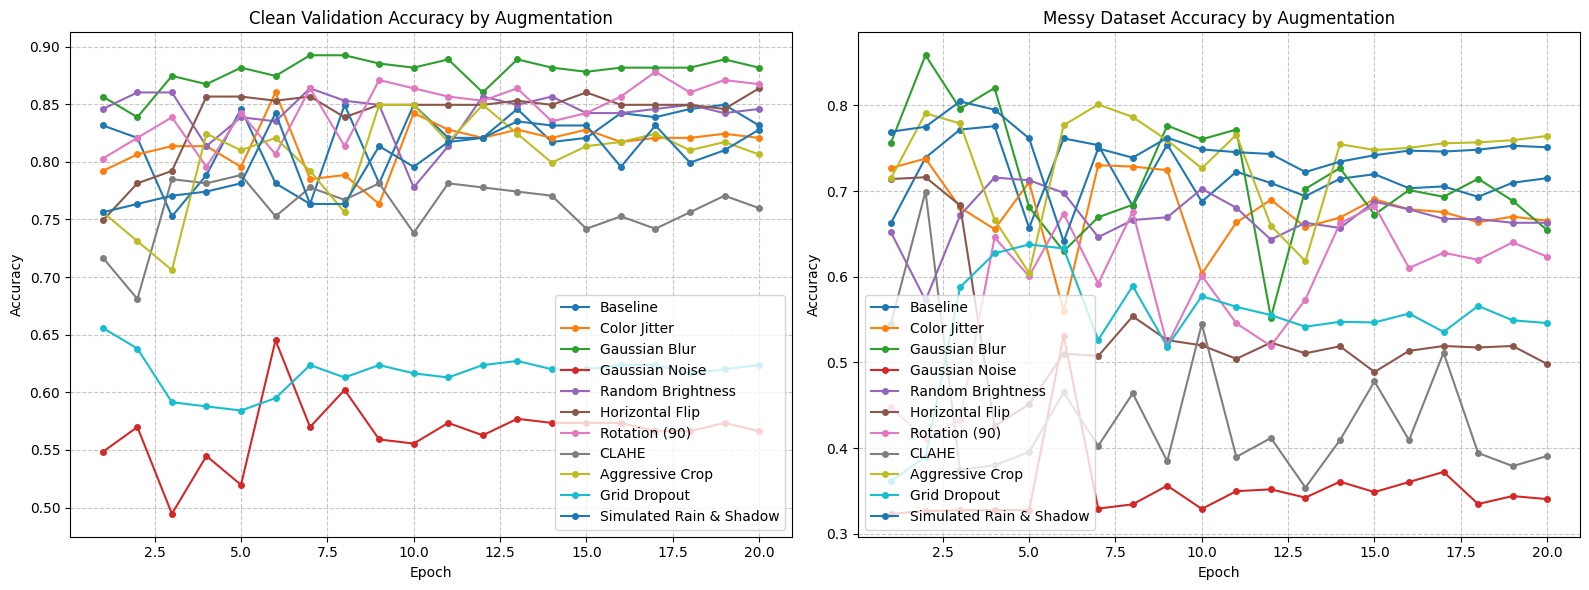

In [5]:
all_histories = {}
num_epochs_to_run = 20 

for aug_name, transform in base_experiments.items():
    print(f"\n{'-'*40}")
    print(f"Starting Experiment: {aug_name}")
    print(f"{'-'*40}")
    
    train_dl, val_dl, eval_dl, t_size, v_size, e_size = get_dataloaders(transform)
    
    start_time = time.time()
    history = train_evaluate_model(
        train_dl, val_dl, eval_dl, 
        t_size, v_size, e_size, 
        num_epochs=num_epochs_to_run
    )
    time_elapsed = time.time() - start_time
    
    print(f"Completed {aug_name} in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    all_histories[aug_name] = history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for aug_name, history in all_histories.items():
    epochs = range(1, len(history['val_acc']) + 1)
    ax1.plot(epochs, history['val_acc'], label=aug_name, marker='o', markersize=4)
    ax2.plot(epochs, history['drive_acc'], label=aug_name, marker='o', markersize=4)

ax1.set_title('Clean Validation Accuracy by Augmentation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title('Messy Dataset Accuracy by Augmentation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from IPython.display import display

#Epochs from final to average
N_EPOCHS_TO_AVG = 5 

summary_data = []

for aug_name, history in all_histories.items():
    clean_acc = history['val_acc']
    messy_acc = history['drive_acc']
    
    n_last = min(N_EPOCHS_TO_AVG, len(messy_acc))
    final_clean = clean_acc[-1]
    final_messy = messy_acc[-1]
    max_messy = max(messy_acc)
    avg_last_n_messy = np.mean(messy_acc[-n_last:])
    robustness_gap = final_clean - final_messy
    
    summary_data.append({
        'Augmentation': aug_name,
        'Max Messy Acc': max_messy,
        'Final Messy Acc': final_messy,
        f'Avg Messy Acc (Last {n_last})': avg_last_n_messy,
        'Final Clean Acc': final_clean,
        'Clean-Messy Gap': robustness_gap
    })
results_df = pd.DataFrame(summary_data)
results_df = results_df.sort_values(by=f'Avg Messy Acc (Last {n_last})', ascending=False).reset_index(drop=True)
format_dict = {
    'Max Messy Acc': '{:.2%}',
    'Final Messy Acc': '{:.2%}',
    f'Avg Messy Acc (Last {n_last})': '{:.2%}',
    'Final Clean Acc': '{:.2%}',
    'Clean-Messy Gap': '{:.2%}'
}
display(results_df.style.format(format_dict))

,Augmentation,Max Messy Acc,Final Messy Acc,Avg Messy Acc (Last 5),Final Clean Acc,Clean-Messy Gap
0,Aggressive Crop,80.10%,76.43%,75.73%,80.65%,4.22%
1,Simulated Rain & Shadow,80.46%,75.11%,74.91%,82.80%,7.69%
2,Baseline,77.57%,71.50%,70.53%,83.15%,11.65%
3,Gaussian Blur,85.84%,65.44%,69.04%,88.17%,22.73%
4,Color Jitter,73.79%,66.55%,67.07%,82.08%,15.53%
5,Random Brightness,71.58%,66.30%,66.79%,84.59%,18.29%
6,Rotation (90),68.30%,62.34%,62.43%,86.74%,24.40%
7,Grid Dropout,63.77%,54.60%,55.08%,62.37%,7.77%
8,Horizontal Flip,71.61%,49.82%,51.36%,86.38%,36.56%
9,CLAHE,69.94%,39.09%,41.70%,75.99%,36.90%


## Combining Augmentation Techniques

In [7]:
combo_experiments = {

    "Combo: Color Jitter + Crop": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.05, p=0.5),
        A.RandomResizedCrop(size=(224, 224), scale=(0.3, 0.8), p=0.5),
        *norm_and_tensor
    ])),

    "Combo: Blur + Grid Dropout": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.GaussianBlur(blur_limit=(5, 9), sigma_limit=(0.1, 2.0), p=0.5),
        A.GridDropout(ratio=0.2, random_offset=True, p=0.5),
        *norm_and_tensor
    ])),

    "Combo: Gaussian Noise + Random Brightness": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.GaussNoise(std_range=(0.1, 0.2), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        *norm_and_tensor
    ])),

    "Combo: Flip + CLAHE": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),
        *norm_and_tensor
    ])),

    "Combo: Rotate + Rain/Shadow": AlbumentationsWrapper(A.Compose([
        A.Resize(224, 224),
        A.Rotate(limit=90, p=0.5),
        A.RandomShadow(p=0.5),
        A.RandomRain(p=0.5),
        *norm_and_tensor
    ]))
}


----------------------------------------
Starting Experiment: Combo: Color Jitter + Crop
----------------------------------------
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 186MB/s] 


Completed Combo: Color Jitter + Crop in 7m 33s

----------------------------------------
Starting Experiment: Combo: Blur + Grid Dropout
----------------------------------------
Completed Combo: Blur + Grid Dropout in 7m 16s

----------------------------------------
Starting Experiment: Combo: Gaussian Noise + Random Brightness
----------------------------------------
Completed Combo: Gaussian Noise + Random Brightness in 7m 18s

----------------------------------------
Starting Experiment: Combo: Flip + CLAHE
----------------------------------------
Completed Combo: Flip + CLAHE in 7m 20s

----------------------------------------
Starting Experiment: Combo: Rotate + Rain/Shadow
----------------------------------------
Completed Combo: Rotate + Rain/Shadow in 7m 27s


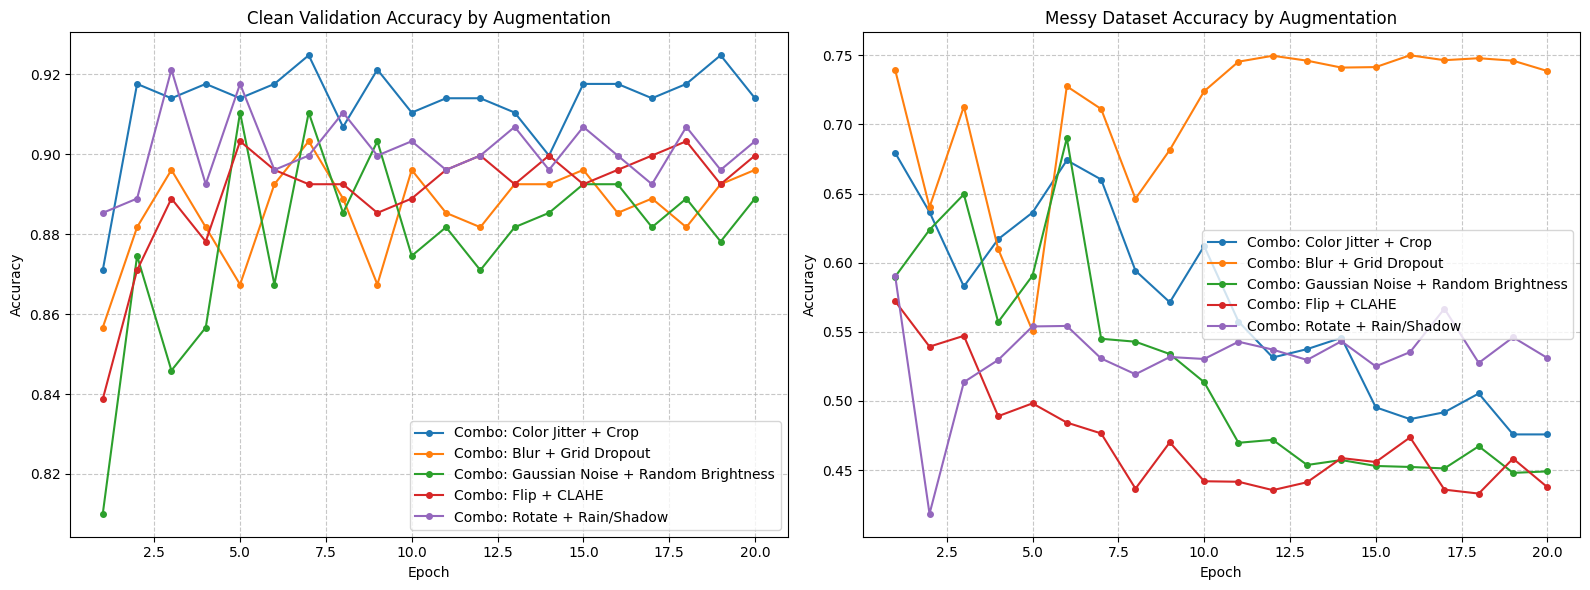

In [8]:
all_histories = {}
num_epochs_to_run = 20

for aug_name, transform in combo_experiments.items():
    print(f"\n{'-'*40}")
    print(f"Starting Experiment: {aug_name}")
    print(f"{'-'*40}")
    
    train_dl, val_dl, eval_dl, t_size, v_size, e_size = get_dataloaders(transform)
    
    start_time = time.time()
    history = train_evaluate_model(
        train_dl, val_dl, eval_dl, 
        t_size, v_size, e_size, 
        num_epochs=num_epochs_to_run,
        train_deeper=True,
        lr = 0.0001
    )
    time_elapsed = time.time() - start_time
    
    print(f"Completed {aug_name} in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    all_histories[aug_name] = history


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for aug_name, history in all_histories.items():
    epochs = range(1, len(history['val_acc']) + 1)
    ax1.plot(epochs, history['val_acc'], label=aug_name, marker='o', markersize=4)
    ax2.plot(epochs, history['drive_acc'], label=aug_name, marker='o', markersize=4)

ax1.set_title('Clean Validation Accuracy by Augmentation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title('Messy Dataset Accuracy by Augmentation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np
from IPython.display import display

N_EPOCHS_TO_AVG = 5 

summary_data = []

for aug_name, history in all_histories.items():
    clean_acc = history['val_acc']
    messy_acc = history['drive_acc']
    
    n_last = min(N_EPOCHS_TO_AVG, len(messy_acc))
    final_clean = clean_acc[-1]
    final_messy = messy_acc[-1]
    max_messy = max(messy_acc)
    avg_last_n_messy = np.mean(messy_acc[-n_last:])
    robustness_gap = final_clean - final_messy
    
    summary_data.append({
        'Augmentation': aug_name,
        'Max Messy Acc': max_messy,
        'Final Messy Acc': final_messy,
        f'Avg Messy Acc (Last {n_last})': avg_last_n_messy,
        'Final Clean Acc': final_clean,
        'Clean-Messy Gap': robustness_gap
    })
results_df = pd.DataFrame(summary_data)
results_df = results_df.sort_values(by=f'Avg Messy Acc (Last {n_last})', ascending=False).reset_index(drop=True)
format_dict = {
    'Max Messy Acc': '{:.2%}',
    'Final Messy Acc': '{:.2%}',
    f'Avg Messy Acc (Last {n_last})': '{:.2%}',
    'Final Clean Acc': '{:.2%}',
    'Clean-Messy Gap': '{:.2%}'
}
display(results_df.style.format(format_dict))

,Augmentation,Max Messy Acc,Final Messy Acc,Avg Messy Acc (Last 5),Final Clean Acc,Clean-Messy Gap
0,Combo: Color Jitter + Crop,74.18%,68.19%,69.08%,87.10%,18.91%
1,Combo: Blur + Grid Dropout,82.17%,69.69%,65.90%,82.80%,13.11%
2,Combo: Chaos Augmentation,74.57%,58.59%,57.55%,82.08%,23.48%
3,Combo: Gaussian Noise + Random Brightness,83.35%,46.47%,44.91%,84.23%,37.76%
